# **Final Project**

**Name:** Hugo Hoyer

**UID:** U1505072

# EDA

**Imports**

In [38]:
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

import requests

import scipy.stats as stats
import statsmodels.formula.api as smf

from bs4 import BeautifulSoup

## Formulate your questions



What is the relationship between the ratings, both critic and audience, and the gross profit of various movies?

Are user or critic ratings more correlated with profit?

Are the ratings more correlated with worldwide gross, domestic gross, or foreign gross?

How does release year correlate with everything?

## Read in and Begin Cleaning the Data



***Read In Data***

In [39]:
IMDb_url = "https://raw.githubusercontent.com/hahhoyer/DS2500_Final_Project/refs/heads/main/imdb_top_250.csv"
df_IMDb = pd.read_csv(IMDb_url)
df_IMDb.drop(columns=["Rank"], inplace=True)

df_IMDb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    250 non-null    object 
 1   Year     250 non-null    int64  
 2   Rating   250 non-null    float64
 3   Runtime  250 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 7.9+ KB


In [40]:
RT_url = "https://editorial.rottentomatoes.com/guide/best-movies-of-all-time/"
headers = {"User-Agent": "Mozilla/5.0"}

RT_html = requests.get(RT_url, headers=headers).text
RT_soup = BeautifulSoup(RT_html, "html.parser")

RT_rows = []

for tr in RT_soup.select("table tr"):
    score_tag = tr.select_one(".tMeterScore")
    title_tag = tr.select_one("a.meta-title")
    year_tag = tr.select_one(".meta-year")

    if not score_tag or not title_tag or not year_tag:
        continue

    RT_rows.append({
        "RT_Rating": score_tag.get_text(strip=True),
        "Title": title_tag.get_text(strip=True),
    })

df_RT = pd.DataFrame(RT_rows)
df_RT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   RT_Rating  300 non-null    object
 1   Title      300 non-null    object
dtypes: object(2)
memory usage: 4.8+ KB


In [41]:
def get_df(url):
    html = requests.get(url, headers=headers).text
    soup = BeautifulSoup(html, "html.parser")

    rows = []

    for tr in soup.select("table tr"):
        cells = tr.find_all("td")
        if len(cells) < 8:
            continue

        rank = cells[0].get_text(strip=True)
        title = cells[1].get_text(strip=True)
        worldwide = cells[2].get_text(strip=True)
        domestic = cells[3].get_text(strip=True)
        domestic_pct = cells[4].get_text(strip=True)
        foreign = cells[5].get_text(strip=True)
        foreign_pct = cells[6].get_text(strip=True)
        year = cells[7].get_text(strip=True)

        rows.append({
            "Title": title,
            "Worldwide_Gross": worldwide,
            "Domestic_Gross": domestic,
            "Domestic_Pct": domestic_pct,
            "Foreign_Gross": foreign,
            "Foreign_Pct": foreign_pct,
        })

    df = pd.DataFrame(rows)
    return df

BOM200_url = "https://www.boxofficemojo.com/chart/ww_top_lifetime_gross/?area=XWW"
BOM400_url = "https://www.boxofficemojo.com/chart/ww_top_lifetime_gross/?area=XWW&offset=200"
BOM600_url = "https://www.boxofficemojo.com/chart/ww_top_lifetime_gross/?area=XWW&offset=400"
BOM800_url = "https://www.boxofficemojo.com/chart/ww_top_lifetime_gross/?area=XWW&offset=600"
BOM1000_url = "https://www.boxofficemojo.com/chart/ww_top_lifetime_gross/?area=XWW&offset=800"

df_BOM200 = get_df(BOM200_url)
df_BOM400 = get_df(BOM400_url)
df_BOM600 = get_df(BOM600_url)
df_BOM800 = get_df(BOM800_url)
df_BOM1000 = get_df(BOM1000_url)

df_BOM = pd.concat([df_BOM200, df_BOM400, df_BOM600, df_BOM800, df_BOM1000])
df_BOM.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 199
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            1000 non-null   object
 1   Worldwide_Gross  1000 non-null   object
 2   Domestic_Gross   1000 non-null   object
 3   Domestic_Pct     1000 non-null   object
 4   Foreign_Gross    1000 non-null   object
 5   Foreign_Pct      1000 non-null   object
dtypes: object(6)
memory usage: 54.7+ KB


***Clean Data***

In [42]:
df_IMDb.rename(columns={"Rating": "IMDb_Rating"}, inplace=True)
df_IMDb["IMDb_Rating"] = (df_IMDb["IMDb_Rating"] * 10)

df_RT["RT_Rating"] = df_RT["RT_Rating"].str.replace("%", "").astype(float)

money_cols = ["Worldwide_Gross", "Domestic_Gross", "Foreign_Gross"]

for col in money_cols:
    df_BOM[col] = pd.to_numeric(df_BOM[col].str.replace("$", "").str.replace(",", "").replace("-", pd.NA), errors="coerce")

## Merge Data

In [43]:
movies = df_IMDb.merge(df_RT, on="Title", how="left")
movies = movies.merge(df_BOM, on="Title", how="left")

movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            254 non-null    object 
 1   Year             254 non-null    int64  
 2   IMDb_Rating      254 non-null    float64
 3   Runtime          254 non-null    int64  
 4   RT_Rating        93 non-null     float64
 5   Worldwide_Gross  73 non-null     float64
 6   Domestic_Gross   73 non-null     float64
 7   Domestic_Pct     73 non-null     object 
 8   Foreign_Gross    73 non-null     float64
 9   Foreign_Pct      73 non-null     object 
dtypes: float64(5), int64(2), object(3)
memory usage: 20.0+ KB


## Clean and Impute the Data

***Impute Data***

In [44]:
avg_RT = movies["RT_Rating"].mean()
new_RT = (movies["IMDb_Rating"] + avg_RT) / 2

movies["RT_Rating"].fillna(new_RT, inplace=True)
movies.dropna(inplace=True)

movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73 entries, 1 to 235
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            73 non-null     object 
 1   Year             73 non-null     int64  
 2   IMDb_Rating      73 non-null     float64
 3   Runtime          73 non-null     int64  
 4   RT_Rating        73 non-null     float64
 5   Worldwide_Gross  73 non-null     float64
 6   Domestic_Gross   73 non-null     float64
 7   Domestic_Pct     73 non-null     object 
 8   Foreign_Gross    73 non-null     float64
 9   Foreign_Pct      73 non-null     object 
dtypes: float64(5), int64(2), object(3)
memory usage: 6.3+ KB


/tmp/ipykernel_23176/3437993276.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movies["RT_Rating"].fillna(new_RT, inplace=True)


## Check the packaging

In [45]:
movies.shape

(73, 10)

## Look at the top and bottom of data

In [46]:
movies.head()

,Title,Year,IMDb_Rating,Runtime,RT_Rating,Worldwide_Gross,Domestic_Gross,Domestic_Pct,Foreign_Gross,Foreign_Pct
1,The Godfather,1972,92.0,175,97.000000,2.509331e+08,136381073.0,54.4%,114551980.0,45.6%
2,The Dark Knight,2008,90.0,152,94.000000,1.008477e+09,534987076.0,53%,473490306.0,47%
5,Schindler's List,1993,90.0,195,98.000000,3.221612e+08,96898818.0,30.1%,225262427.0,69.9%
6,The Lord of the Rings: The Return of the King,2003,89.0,201,93.043011,1.149079e+09,386975644.0,33.7%,762103643.0,66.3%
7,Pulp Fiction,1994,89.0,154,92.000000,2.139288e+08,107928762.0,50.4%,106000000.0,49.6%


In [47]:
movies.tail()

,Title,Year,IMDb_Rating,Runtime,RT_Rating,Worldwide_Gross,Domestic_Gross,Domestic_Pct,Foreign_Gross,Foreign_Pct
230,Beauty and the Beast,1991,80.0,84,95.000000,4.512913e+08,218967620.0,48.5%,232323678.0,51.5%
231,Dead Poets Society,1989,80.0,128,88.543011,2.358601e+08,95860116.0,40.6%,140000000.0,59.4%
233,Aladdin,1992,80.0,90,96.000000,1.054304e+09,355559216.0,33.7%,698744784.0,66.3%
234,Aladdin,1992,80.0,90,96.000000,5.040502e+08,217350219.0,43.1%,286700000.0,56.9%
235,Howl's Moving Castle,2004,80.0,119,88.543011,2.434620e+08,10352604.0,4.2%,233109417.0,95.8%


## Check the "n"s


In [48]:
movies.value_counts()

Title             Year  IMDb_Rating  Runtime  RT_Rating   Worldwide_Gross  Domestic_Gross  Domestic_Pct  Foreign_Gross  Foreign_Pct
1917              2019  83.0         119      90.043011   4.460644e+08     159227644.0     35.7%         286836708.0    64.3%          1
A Beautiful Mind  2001  82.0         135      89.543011   3.167913e+08     170742341.0     53.9%         146048916.0    46.1%          1
Aladdin           1992  80.0         90       96.000000   5.040502e+08     217350219.0     43.1%         286700000.0    56.9%          1
                                                          1.054304e+09     355559216.0     33.7%         698744784.0    66.3%          1
American Beauty   1999  84.0         122      90.543011   3.562966e+08     130096601.0     36.5%         226200000.0    63.5%          1
                                                                                                                                      ..
Toy Story         1995  83.0         81       100.000000  4.011580e+08     229947062.0     57.3%         171210907.0    42.7%          1
Toy Story 3       2010  83.0         103      98.000000   1.067316e+09     415004880.0     38.9%         652311221.0    61.1%          1
Up                2009  82.0         96       98.000000   7.351040e+08     293004164.0     39.9%         442099790.0    60.1%          1
WALL·E            2008  84.0         98       90.543011   5.274048e+08     223808164.0     42.4%         303596618.0    57.6%          1
Your Name.        2016  84.0         106      90.543011   4.056318e+08     5017246.0       1.2%          400614574.0    98.8%          1
Name: count, Length: 73, dtype: int64

## Validate against an external knowledge or data source


For the ratings datasets, the IMDb dataset I downloaded from Kaggle seemed to match the information on IMDb's website (https://www.imdb.com/chart/top/), and the Rotten Tomatoes data was scraped directly from their website so it is as accurate as it can be. For the profit data, I compared the Box Office Mojo data that I scraped with the Wikipedia page (https://en.wikipedia.org/wiki/List_of_highest-grossing_films) for the highest grossing movies, and the data was very similar between the two.

## Plots



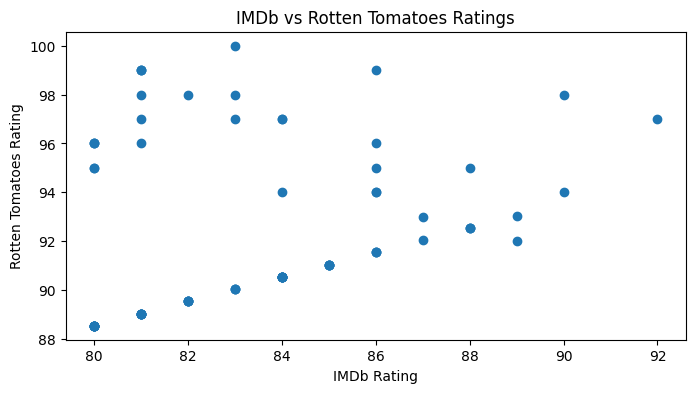

In [49]:
plt.figure(figsize=(8, 4))
plt.scatter(x=movies["IMDb_Rating"], y=movies["RT_Rating"])
plt.title("IMDb vs Rotten Tomatoes Ratings")
plt.xlabel("IMDb Rating")
plt.ylabel("Rotten Tomatoes Rating")
plt.show()

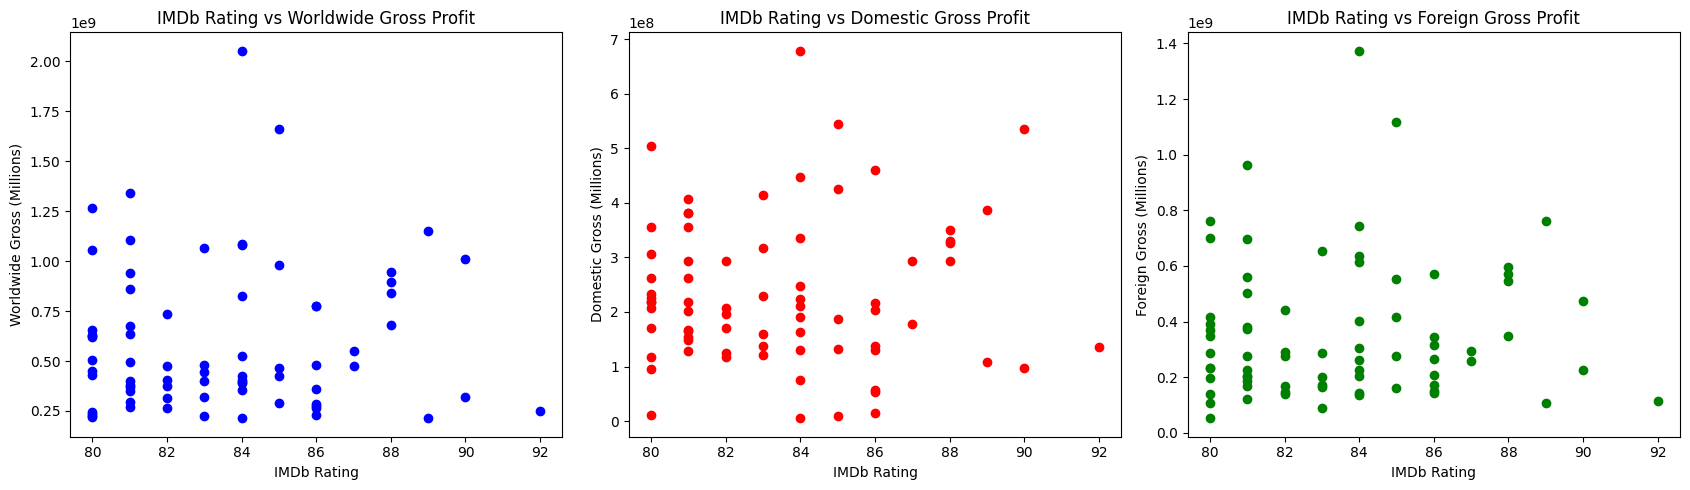

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(x=movies["IMDb_Rating"], y=movies["Worldwide_Gross"], color="blue")
axes[0].set_title("IMDb Rating vs Worldwide Gross Profit")
axes[0].set_xlabel("IMDb Rating")
axes[0].set_ylabel("Worldwide Gross (Millions)")

axes[1].scatter(x=movies["IMDb_Rating"], y=movies["Domestic_Gross"], color="red")
axes[1].set_title("IMDb Rating vs Domestic Gross Profit")
axes[1].set_xlabel("IMDb Rating")
axes[1].set_ylabel("Domestic Gross (Millions)")

axes[2].scatter(x=movies["IMDb_Rating"], y=movies["Foreign_Gross"], color="green")
axes[2].set_title("IMDb Rating vs Foreign Gross Profit")
axes[2].set_xlabel("IMDb Rating")
axes[2].set_ylabel("Foreign Gross (Millions)")

plt.tight_layout()
plt.show()

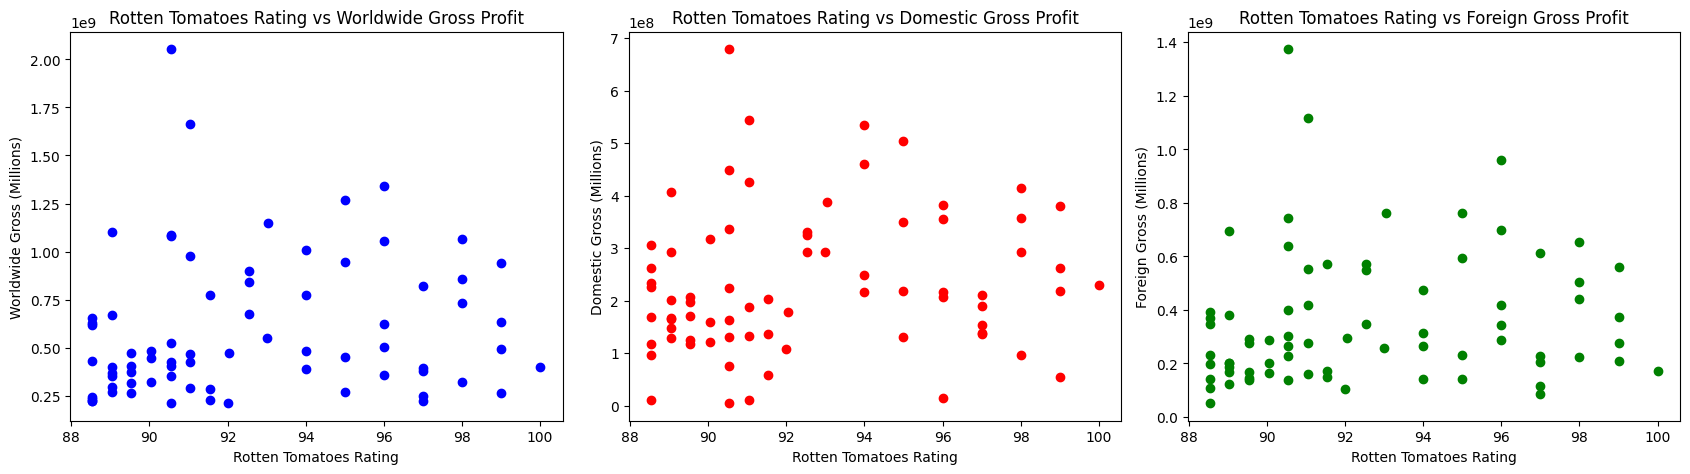

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(x=movies["RT_Rating"], y=movies["Worldwide_Gross"], color="blue")
axes[0].set_title("Rotten Tomatoes Rating vs Worldwide Gross Profit")
axes[0].set_xlabel("Rotten Tomatoes Rating")
axes[0].set_ylabel("Worldwide Gross (Millions)")

axes[1].scatter(x=movies["RT_Rating"], y=movies["Domestic_Gross"], color="red")
axes[1].set_title("Rotten Tomatoes Rating vs Domestic Gross Profit")
axes[1].set_xlabel("Rotten Tomatoes Rating")
axes[1].set_ylabel("Domestic Gross (Millions)")

axes[2].scatter(x=movies["RT_Rating"], y=movies["Foreign_Gross"], color="green")
axes[2].set_title("Rotten Tomatoes Rating vs Foreign Gross Profit")
axes[2].set_xlabel("Rotten Tomatoes Rating")
axes[2].set_ylabel("Foreign Gross (Millions)")

plt.tight_layout()
plt.show()

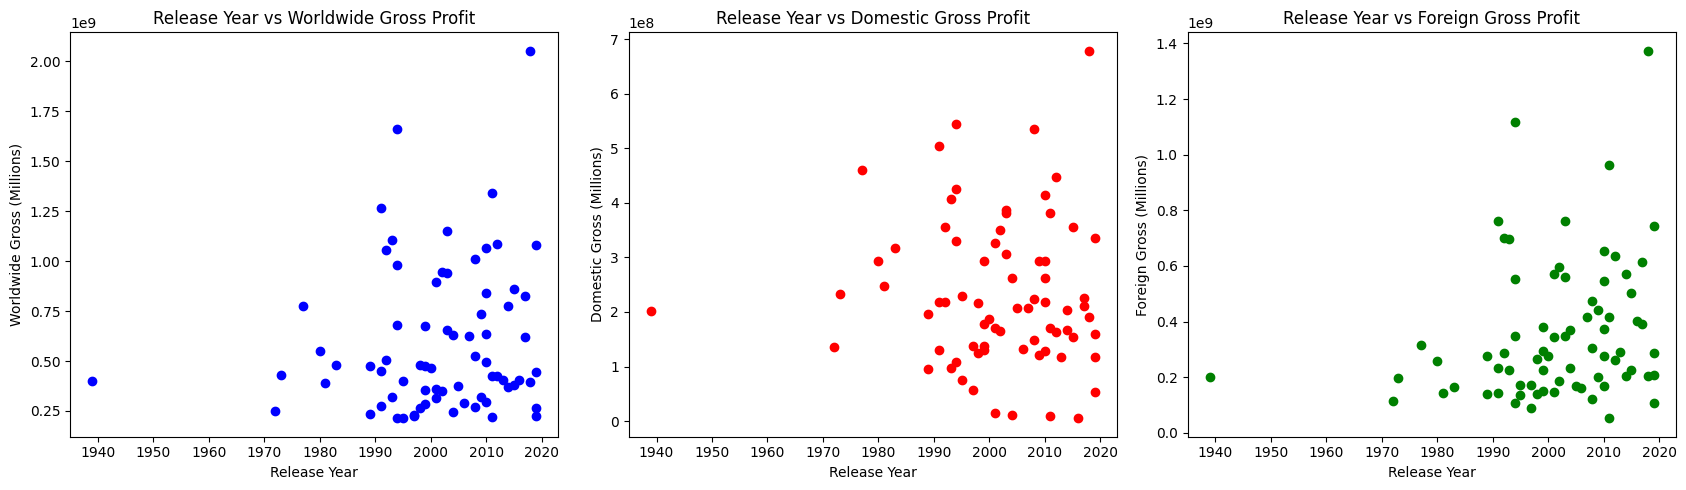

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(x=movies["Year"], y=movies["Worldwide_Gross"], color="blue")
axes[0].set_title("Release Year vs Worldwide Gross Profit")
axes[0].set_xlabel("Release Year")
axes[0].set_ylabel("Worldwide Gross (Millions)")

axes[1].scatter(x=movies["Year"], y=movies["Domestic_Gross"], color="red")
axes[1].set_title("Release Year vs Domestic Gross Profit")
axes[1].set_xlabel("Release Year")
axes[1].set_ylabel("Domestic Gross (Millions)")

axes[2].scatter(x=movies["Year"], y=movies["Foreign_Gross"], color="green")
axes[2].set_title("Release Year vs Foreign Gross Profit")
axes[2].set_xlabel("Release Year")
axes[2].set_ylabel("Foreign Gross (Millions)")

plt.tight_layout()
plt.show()

## Statitical Test and Models


**Normality check**

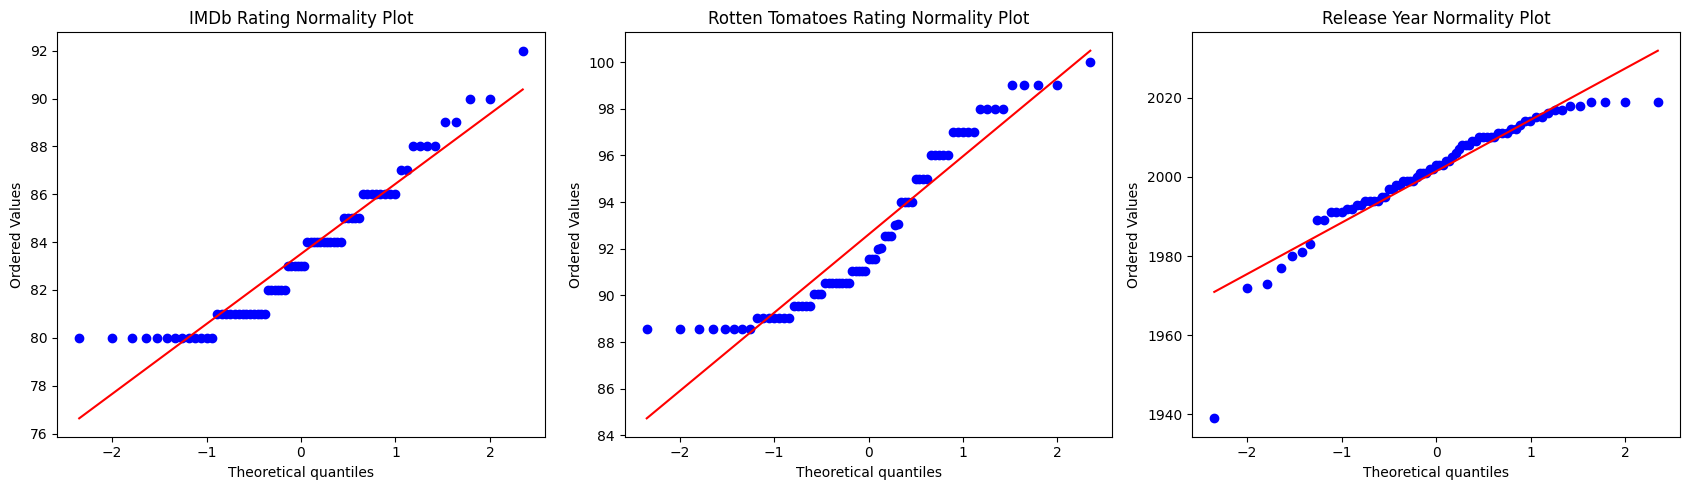

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

stats.probplot(movies["IMDb_Rating"], plot=axes[0])
axes[0].set_title("IMDb Rating Normality Plot")

stats.probplot(movies["RT_Rating"], plot=axes[1])
axes[1].set_title("Rotten Tomatoes Rating Normality Plot")

stats.probplot(movies["Year"], plot=axes[2])
axes[2].set_title("Release Year Normality Plot")

plt.tight_layout()
plt.show()

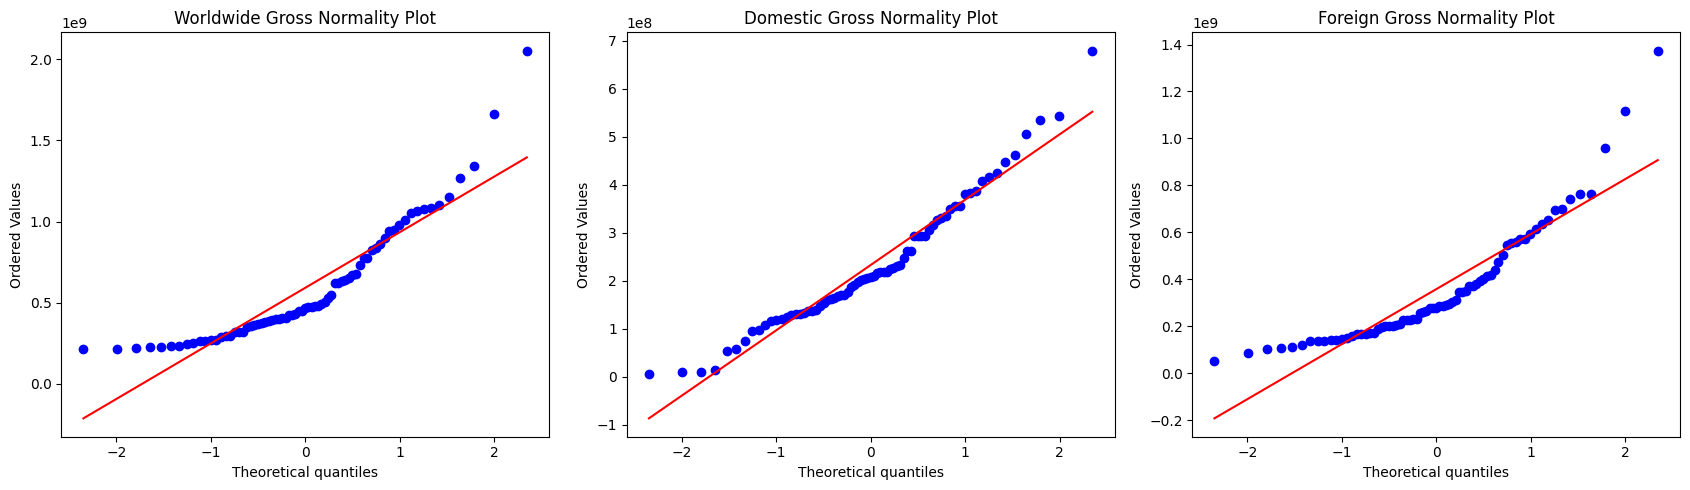

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

stats.probplot(movies["Worldwide_Gross"], plot=axes[0])
axes[0].set_title("Worldwide Gross Normality Plot")

stats.probplot(movies["Domestic_Gross"], plot=axes[1])
axes[1].set_title("Domestic Gross Normality Plot")

stats.probplot(movies["Foreign_Gross"], plot=axes[2])
axes[2].set_title("Foreign Gross Normality Plot")

plt.tight_layout()
plt.show()

**Tests**

In [55]:
IMDb_r, IMDb_p_value = stats.pearsonr(movies["IMDb_Rating"], movies["Worldwide_Gross"])

print("IMDb_Rating/Worldwide_Gross Correlation Coefficient: ", IMDb_r)
print("IMDb_Rating/Worldwide_Gross P-value: ", IMDb_p_value)
print("")

RT_r, RT_p_value = stats.pearsonr(movies["RT_Rating"], movies["Worldwide_Gross"])

print("Rotten_Tomatoes_Rating/Worldwide_Gross Correlation Coefficient: ", RT_r)
print("Rotten_Tomatoes_Rating/Worldwide_Gross P-value: ", RT_p_value)
print("")

year_r, year_p_value = stats.pearsonr(movies["Year"], movies["Worldwide_Gross"])

print("Release_Year/Worldwide_Gross Correlation Coefficient: ", year_r)
print("Release_Year/Worldwide_Gross P-value: ", year_p_value)

IMDb_Rating/Worldwide_Gross Correlation Coefficient:  0.05360635950323847
IMDb_Rating/Worldwide_Gross P-value:  0.6523990935028315

Rotten_Tomatoes_Rating/Worldwide_Gross Correlation Coefficient:  0.13941888561867075
Rotten_Tomatoes_Rating/Worldwide_Gross P-value:  0.2394384941485582

Release_Year/Worldwide_Gross Correlation Coefficient:  0.13888242599399736
Release_Year/Worldwide_Gross P-value:  0.24126918155035612


In [56]:
IMDb_r, IMDb_p_value = stats.pearsonr(movies["IMDb_Rating"], movies["Domestic_Gross"])

print("IMDb_Rating/Domestic_Gross Correlation Coefficient: ", IMDb_r)
print("IMDb_Rating/Domestic_Gross P-value: ", IMDb_p_value)
print("")

RT_r, RT_p_value = stats.pearsonr(movies["RT_Rating"], movies["Domestic_Gross"])

print("Rotten_Tomatoes_Rating/Domestic_Gross Correlation Coefficient: ", RT_r)
print("Rotten_Tomatoes_Rating/Domestic_Gross P-value: ", RT_p_value)
print("")

year_r, year_p_value = stats.pearsonr(movies["Year"], movies["Domestic_Gross"])

print("Release_Year/Domestic_Gross Correlation Coefficient: ", year_r)
print("Release_Year/Domestic_Gross P-value: ", year_p_value)

IMDb_Rating/Domestic_Gross Correlation Coefficient:  0.03781422439519996
IMDb_Rating/Domestic_Gross P-value:  0.7507715912934207

Rotten_Tomatoes_Rating/Domestic_Gross Correlation Coefficient:  0.13311992010992346
Rotten_Tomatoes_Rating/Domestic_Gross P-value:  0.2615429381948198

Release_Year/Domestic_Gross Correlation Coefficient:  -0.05039585485403104
Release_Year/Domestic_Gross P-value:  0.6719889725869864


In [57]:
IMDb_r, IMDb_p_value = stats.pearsonr(movies["IMDb_Rating"], movies["Foreign_Gross"])

print("IMDb_Rating/Foreign_Gross Correlation Coefficient: ", IMDb_r)
print("IMDb_Rating/Foreign_Gross P-value: ", IMDb_p_value)
print("")

RT_r, RT_p_value = stats.pearsonr(movies["RT_Rating"], movies["Foreign_Gross"])

print("Rotten_Tomatoes_Rating/Foreign_Gross Correlation Coefficient: ", RT_r)
print("Rotten_Tomatoes_Rating/Foreign_Gross P-value: ", RT_p_value)
print("")

year_r, year_p_value = stats.pearsonr(movies["Year"], movies["Foreign_Gross"])

print("Release_Year/Foreign_Gross Correlation Coefficient: ", year_r)
print("Release_Year/Foreign_Gross P-value: ", year_p_value)

IMDb_Rating/Foreign_Gross Correlation Coefficient:  0.05759908167062163
IMDb_Rating/Foreign_Gross P-value:  0.6283610716771849

Rotten_Tomatoes_Rating/Foreign_Gross Correlation Coefficient:  0.13082186804248208
Rotten_Tomatoes_Rating/Foreign_Gross P-value:  0.2699404496860374

Release_Year/Foreign_Gross Correlation Coefficient:  0.23021294389638283
Release_Year/Foreign_Gross P-value:  0.05006644190843988


**Regression Models**

In [58]:
linear_model = smf.ols(formula="Worldwide_Gross ~ IMDb_Rating + RT_Rating", data=movies).fit()
linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Worldwide_Gross   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.7158
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.492
Time:                        23:11:37   Log-Likelihood:                -1541.6
No. Observations:                  73   AIC:                             3089.
Df Residuals:                      70   BIC:                             3096.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -9.787e+08   1.52e+09     -0.644      0.522   -4.01e+09    2.05e+09
IMDb_Rating  3.076e+06   1.48e+07      0.208      0.836   -2.64e+07    3.26e+07
RT_Rating    1.418e+07   1.28e+07      1.107      0.272   -1.14e+07    3.97e+07
==============================================================================
Omnibus:                       32.143   Durbin-Watson:                   1.927
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               62.162
Skew:                           1.593   Prob(JB):                     3.17e-14
Kurtosis:                       6.206   Cond. No.                     4.42e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.42e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [59]:
quadratic_model = smf.ols(formula="Worldwide_Gross ~ IMDb_Rating + I(IMDb_Rating**2) + RT_Rating + I(RT_Rating**2)", data=movies).fit()
quadratic_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Worldwide_Gross   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     1.728
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.154
Time:                        23:11:37   Log-Likelihood:                -1538.8
No. Observations:                  73   AIC:                             3088.
Df Residuals:                      68   BIC:                             3099.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.105e+11   5.09e+10     -2.172      0.033   -2.12e+11   -8.97e+09
IMDb_Rating          5.248e+07   7.39e+08      0.071      0.944   -1.42e+09    1.53e+09
I(IMDb_Rating ** 2) -4.314e+05   4.36e+06     -0.099      0.921   -9.13e+06    8.27e+06
RT_Rating            2.332e+09   1.03e+09      2.265      0.027    2.78e+08    4.39e+09
I(RT_Rating ** 2)   -1.236e+07   5.49e+06     -2.251      0.028   -2.33e+07    -1.4e+06
==============================================================================
Omnibus:                       31.949   Durbin-Watson:                   1.850
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               64.556
Skew:                           1.547   Prob(JB):                     9.59e-15
Kurtosis:                       6.414   Cond. No.                     1.35e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.35e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""